### import Liberary

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Import Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samybaladram/multidisciplinary-csv-datasets-collection")

print("Path to dataset files:", path)

/home/md-naim/miniconda3/envs/ML/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/md-naim/.cache/kagglehub/datasets/samybaladram/multidisciplinary-csv-datasets-collection/versions/5


In [3]:
from pathlib import Path

dataset_files = list(Path(path).rglob("*.csv"))

In [4]:
data = pd.read_csv(dataset_files[0])

In [5]:
data.head()

,Index,"""Mass (kg)""","""Spring 1 (m)""","""Spring 2 (m)"""
0,1,0.00,0.050,0.050
1,2,0.49,0.066,0.066
2,3,0.98,0.087,0.080
3,4,1.47,0.116,0.108
4,5,1.96,0.142,0.138


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Index            10 non-null     int64  
 1    "Mass (kg)"     10 non-null     float64
 2    "Spring 1 (m)"  10 non-null     float64
 3    "Spring 2 (m)"  10 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 448.0 bytes


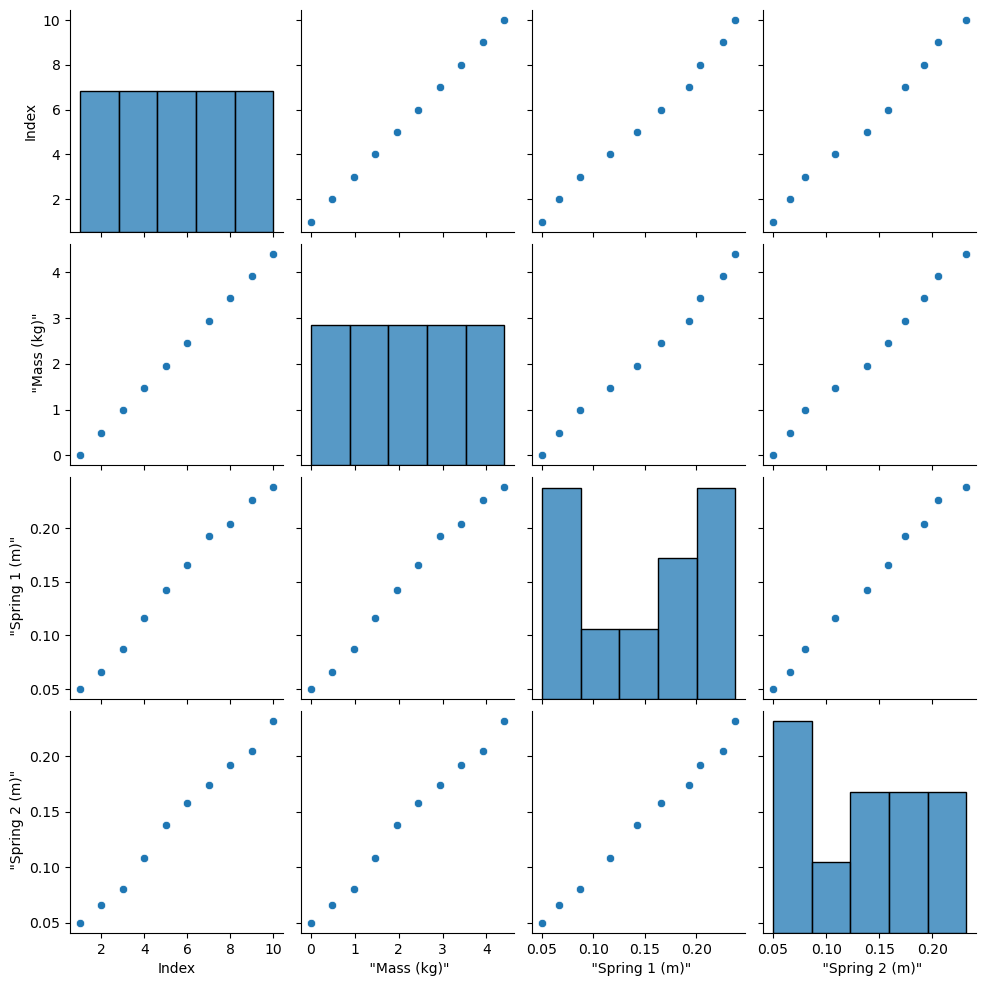

In [7]:
sns.pairplot(
    data=data
)

In [11]:
data.columns = data.columns.str.strip().str.strip('"')

feature = data.drop(columns=['Spring 2 (m)'])


In [12]:
target = data['Spring 2 (m)']


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_trin, X_test, y_train, y_test = train_test_split(
    feature,
    target,
    train_size=.90,
    random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_trin, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
model.coef_

array([0.007353  , 0.00360297, 0.53397601])

In [17]:
model.intercept_

np.float64(0.01339583230932026)

In [18]:
prediction = model.predict(X_test)

<Axes: xlabel='Spring 2 (m)'>

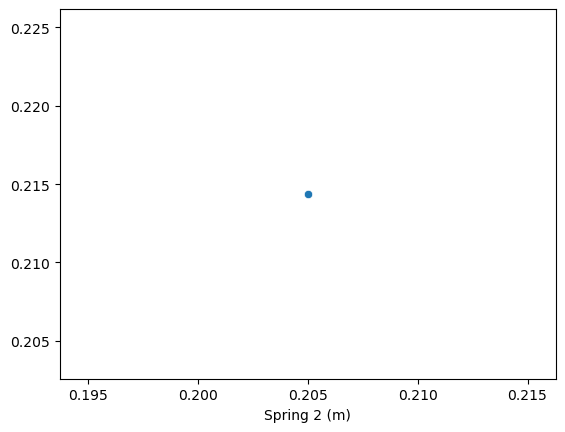

In [19]:
sns.scatterplot(
    x=y_test,
    y=prediction
)

<Axes: xlabel='Spring 2 (m)', ylabel='Count'>

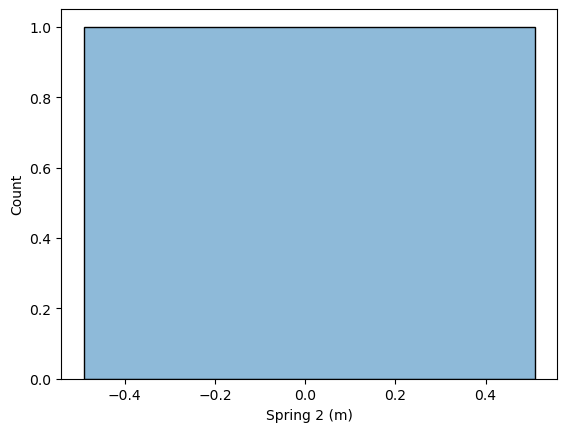

In [20]:
sns.histplot(
    x=prediction-y_test,
    kde=True
)

In [21]:
# Evaluate this model....

from sklearn.metrics import mean_absolute_error, mean_squared_error



In [22]:
MAE = mean_absolute_error(y_test, prediction)
MAE

0.009375040771210041

In [23]:
MSE = mean_squared_error(y_test, prediction)
MSE

8.789138946185056e-05

In [25]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.009375040771210041)